In [1]:
from mmspao.utils import *
from mmspao import mmspao
import scanpy as sc

set_random_seed(42)
device = 'cuda'


In [2]:
#Load data and perform necessary preprocessing
rna = sc.read('/home/data1/linjing0806/multiomics/SpatialGlue/data/Sim_tri/adata_RNA.h5ad')
adata = rna.copy()
rna = getX(rna,modality='rna')

protein = sc.read('/home/data1/linjing0806/multiomics/SpatialGlue/data/Sim_tri/adata_ADT.h5ad')
protein = getX(protein,modality='protein')

atac = sc.read("/home/data1/linjing0806/multiomics/SpatialGlue/data/Sim_tri/adata_ATAC.h5ad")
atac = getX(atac, modality='atac')

In [3]:
#if using a subset of modality-specific terms, the "sel_views" parameter should be a list with values entries to the indices of the modalities to be included, e.g.,  ind_views=[0,2] if including RNA and image features
#if using a subset of interaction terms, the "combination" parameter should be a list of tuples with entries to the indices of the modalities for each interaction, e.g. combs = [(0,1),(0,2)] if including the RNA-protein and RNA-image interaction terms
model = mmspao([rna,protein,atac],sel_views='all',combination='all',sparse=False,device=device)
model.train(2000)
# np.save('emb.npy', model.emb)

perform PCA for each modality:   0%|          | 0/3 [00:00<?, ?it/s]

Training KAN for modality 1:   0%|          | 0/2000 [00:00<?, ?it/s]

Training KAN for modality 2:   0%|          | 0/2000 [00:00<?, ?it/s]

Training KAN for modality 3:   0%|          | 0/2000 [00:00<?, ?it/s]

In [4]:
model.cluster(adata, n_domains=5, end=0.7)

Leiden clustering:   0%|          | 0/60 [00:00<?, ?it/s]

Found resolution: 0.50 for 5 domains


0.4999999999999998

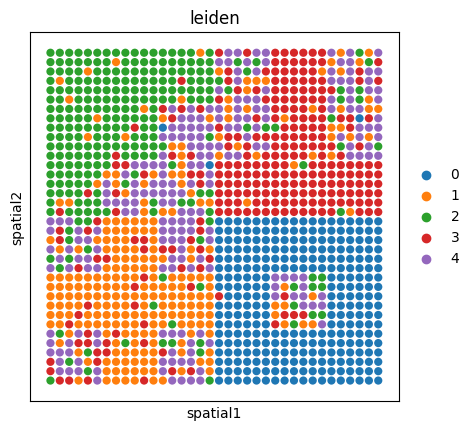

In [5]:
sc.pl.spatial(adata, color="leiden", spot_size=0.1, show=True)

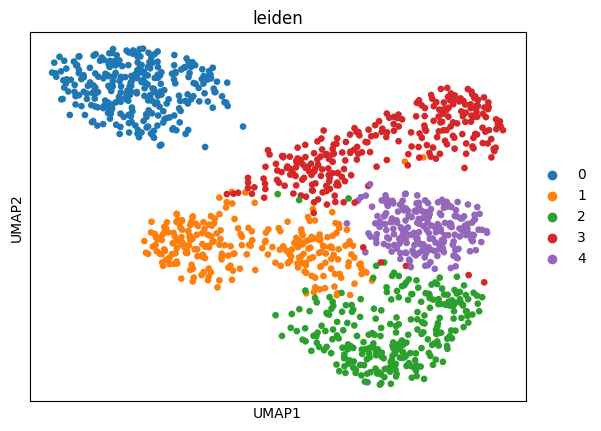

In [6]:
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden",)